# 00_1 — Datenübersicht für Global-6-HPO und Transfer

Dieses Notebook beschreibt exakt die Datenbasis von Notebook 00 und dem anschließenden Transferworkflow. Es trennt dabei drei Dinge sauber:

- **vorhandene Gasgemisch-Komponenten** in der ursprünglichen Dennis-Kalibration,
- **tatsächlich trainierte Zielgröße:** ausschließlich Aceton in ppb,
- **verwendete Sensorsignale:** Subsensor 0 von sechs Quellgeräten; Gerät 7 bleibt Transferziel.

Eine UGM ist eine eindeutige Gasgemisch-/Messzustandsgruppe. Zu einer UGM können mehrere zeitlich aufgenommene Zyklen gehören. Dieselben Messzeilen liegen ausgerichtet für alle sieben Geräte vor.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
from html import escape
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from scipy.io import loadmat, whosmat

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / 'Data' / 'Dennis' / 'Prepared').exists())
PREPARED = ROOT / 'Data' / 'Dennis' / 'Prepared'
RAW_CAL1 = ROOT / 'Data' / 'Dennis' / 'Zenodo_First_Calibration.mat'
TARGET_FILE = PREPARED / 'dennis_targets_leakage_safe.mat'
sys.path[:0] = [str(ROOT / 'Networks'), str(ROOT / 'Evaluation Seminar' / 'Day_03'),
                str(ROOT / 'Evaluation Seminar' / 'Day_04')]
from day4_utils import load_sensor_domains

def show_table(rows):
    if not rows:
        return display(HTML('<em>Keine Daten</em>'))
    columns = list(rows[0])
    header = ''.join(f'<th>{escape(str(col))}</th>' for col in columns)
    body = ''.join('<tr>' + ''.join(f'<td>{escape(str(row[col]))}</td>' for col in columns) + '</tr>' for row in rows)
    display(HTML(f'<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>'))

GAS_LABELS = {
    'acetone': 'Aceton', 'carbonMonoxide': 'Kohlenmonoxid',
    'ethanol': 'Ethanol', 'ethylAcetate': 'Ethylacetat',
    'formaldehyde': 'Formaldehyd', 'hydrogen': 'Wasserstoff',
    'toluene': 'Toluol'
}
SPLIT_NAMES = {0: 'ungültig/ungenutzt', 1: 'Train', 2: 'Validation', 3: 'Test'}
print('Ursprungsdatei:', RAW_CAL1)
print('Leakage-sichere Targets:', TARGET_FILE)

Ursprungsdatei: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\Dennis\Zenodo_First_Calibration.mat
Leakage-sichere Targets: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\Dennis\Prepared\dennis_targets_leakage_safe.mat


## 1. Welche Zielgrößen sind ursprünglich vorhanden?

Kalibration 1 enthält sieben Gaskonzentrationen. `water` beschreibt die relative Feuchte und `states` den Messzustand. Das aktuelle Day-4-Modell ist trotzdem ein **Single-Target-Regressor für Aceton**; die übrigen Komponenten werden nicht als Labels vorhergesagt.

In [2]:
raw_target = loadmat(RAW_CAL1, simplify_cells=True)['target']
prepared_target = loadmat(TARGET_FILE, simplify_cells=True)
gas_keys = [key for key in GAS_LABELS if key in raw_target]
print('Gas-Komponenten Kalibration 1:', len(gas_keys))
print(', '.join(GAS_LABELS[key] for key in gas_keys))
print('Weitere Ziel-/Metadatenfelder:', sorted(set(raw_target) - set(gas_keys)))
print('Für Day 4 vorbereitete Felder:',
      sorted(key for key in prepared_target if not key.startswith('__')))
print('Trainierte Zielgröße: Aceton [ppb]')

Gas-Komponenten Kalibration 1: 7
Aceton, Kohlenmonoxid, Ethanol, Ethylacetat, Formaldehyd, Wasserstoff, Toluol
Weitere Ziel-/Metadatenfelder: ['states', 'water']
Für Day 4 vorbereitete Felder: ['acetone', 'calibration', 'range', 'split_code', 'state', 'unixtime']
Trainierte Zielgröße: Aceton [ppb]


## 2. Exakter Ausschnitt des Global-6-HPO

Kalibration 1 enthält **199 definierte UGMs**. Drei davon können nicht zuverlässig mit den vorbereiteten Sensordaten gepaart werden, sodass **196 auswertbare UGMs** verbleiben. Davon werden 40 als unangetasteter Testsplit zurückgehalten. Die HPO verwendet deshalb 137 Train- plus 19 Validierungs-UGMs, also **156 Entwicklungs-UGMs**. Der Testsplit und sämtliche Daten von Gerät 7 bleiben aus Training und Hyperparameterwahl ausgeschlossen.

In [3]:
domains, audit = load_sensor_domains(channel=0, calibration=1, gas='acetone')
sensors = list(domains); sources, transfer_target = sensors[:6], sensors[6]
scope = [
    {'Eigenschaft': 'Quellgeräte im Global-6-HPO', 'Wert': ', '.join(sources)},
    {'Eigenschaft': 'Ausgeschlossenes Transferziel', 'Wert': transfer_target},
    {'Eigenschaft': 'verwendeter Subsensor', 'Wert': '0 von 4'},
    {'Eigenschaft': 'Samples je Zyklus', 'Wert': 1440},
    {'Eigenschaft': 'Modellinput je Beobachtung', 'Wert': '(1, 1440, 1)'},
    {'Eigenschaft': 'Zielvariable', 'Wert': 'Aceton [ppb]'},
    {'Eigenschaft': 'Kalibration', 'Wert': 1},
    {'Eigenschaft': 'HPO-Splits', 'Wert': 'Train + Validation'},
    {'Eigenschaft': 'nicht für HPO verwendet', 'Wert': 'Testsplit und Gerät 7'},
]
show_table(scope)

Eigenschaft,Wert
Quellgeräte im Global-6-HPO,"54118801, 54120037, 54120457, 54156953, 84746449, 84748697"
Ausgeschlossenes Transferziel,84749569
verwendeter Subsensor,0 von 4
Samples je Zyklus,1440
Modellinput je Beobachtung,"(1, 1440, 1)"
Zielvariable,Aceton [ppb]
Kalibration,1
HPO-Splits,Train + Validation
nicht für HPO verwendet,Testsplit und Gerät 7


## 3. Zyklen, UGMs und gepoolte Modellbeobachtungen

Ein physischer Messzyklus wird gleichzeitig von allen Geräten erfasst. Beim Pooling der sechs Quellgeräte entstehen deshalb sechs Modellbeobachtungen pro gültiger Messzeile. Die UGM-Auswertung bleibt sensorgetrennt, damit dieselbe Gasgemisch-ID verschiedener Geräte nicht fälschlich zu einer einzigen Vorhersage gemittelt wird.

In [4]:
cal1 = np.asarray(prepared_target['calibration']).ravel() == 1
split_code = np.asarray(prepared_target['split_code']).ravel()
group_id = np.asarray(prepared_target['range'], dtype=float).ravel()
target_y = np.asarray(prepared_target['acetone'], dtype=float).ravel()
defined = cal1 & np.isfinite(group_id) & np.isfinite(target_y)
eligible = cal1 & np.isin(split_code, [1, 2, 3]) & np.isfinite(group_id)
excluded_defined = defined & (split_code == 0)
overview_rows = [
    {'Stufe': 'definiert in Kalibration 1', 'UGMs': len(np.unique(group_id[defined])), 'Zyklen': int(defined.sum()), 'Verwendung': 'vollständiger gelabelter Rohbestand'},
    {'Stufe': 'auswertbar/gepaart', 'UGMs': len(np.unique(group_id[eligible])), 'Zyklen': int(eligible.sum()), 'Verwendung': 'Train + Validation + Test'},
    {'Stufe': 'Entwicklung/HPO', 'UGMs': audit['groups']['train'] + audit['groups']['val'], 'Zyklen': audit['rows']['train'] + audit['rows']['val'], 'Verwendung': 'Train + Validation'},
    {'Stufe': 'unangetasteter Test', 'UGMs': audit['groups']['test'], 'Zyklen': audit['rows']['test'], 'Verwendung': 'nur finale Bewertung'},
]
show_table(overview_rows)
print(f"Nicht paarbar: {len(np.unique(group_id[excluded_defined]))} UGMs mit {excluded_defined.sum()} Zyklen.")
print(f"Kalibration 1 enthält außerdem {cal1.sum() - defined.sum()} Hintergrund-/ungelabelte Zeilen ohne definierte UGM.")

split_rows = []
for split in ['train', 'val', 'test']:
    rows = audit['rows'][split]
    ugms = audit['groups'][split]
    split_rows.append({
        'Split': {'train': 'Train', 'val': 'Validation', 'test': 'Test'}[split],
        'physische Messzyklen': rows,
        'eindeutige UGMs': ugms,
        'Global-6 Modellbeobachtungen': rows * 6,
        'sensorgetrennte UGM-Gruppen': ugms * 6,
        'für Global-HPO verwendet': split in {'train', 'val'},
    })
split_df = split_rows
show_table(split_df)
print('HPO gesamt: 688 gültige Messzyklen, davon 602 Train und 86 Validation.')
print('Nach Pooling: 3.612 Trainings- und 516 Validierungsbeobachtungen.')
print('UGMs für HPO: 137 Train + 19 Validation = 156 unterschiedliche Gasgemische.')

Stufe,UGMs,Zyklen,Verwendung
definiert in Kalibration 1,199,879,vollständiger gelabelter Rohbestand
auswertbar/gepaart,196,866,Train + Validation + Test
Entwicklung/HPO,156,688,Train + Validation
unangetasteter Test,40,178,nur finale Bewertung


Nicht paarbar: 3 UGMs mit 13 Zyklen.
Kalibration 1 enthält außerdem 2106 Hintergrund-/ungelabelte Zeilen ohne definierte UGM.


Split,physische Messzyklen,eindeutige UGMs,Global-6 Modellbeobachtungen,sensorgetrennte UGM-Gruppen,für Global-HPO verwendet
Train,602,137,3612,822,True
Validation,86,19,516,114,True
Test,178,40,1068,240,False


HPO gesamt: 688 gültige Messzyklen, davon 602 Train und 86 Validation.
Nach Pooling: 3.612 Trainings- und 516 Validierungsbeobachtungen.
UGMs für HPO: 137 Train + 19 Validation = 156 unterschiedliche Gasgemische.


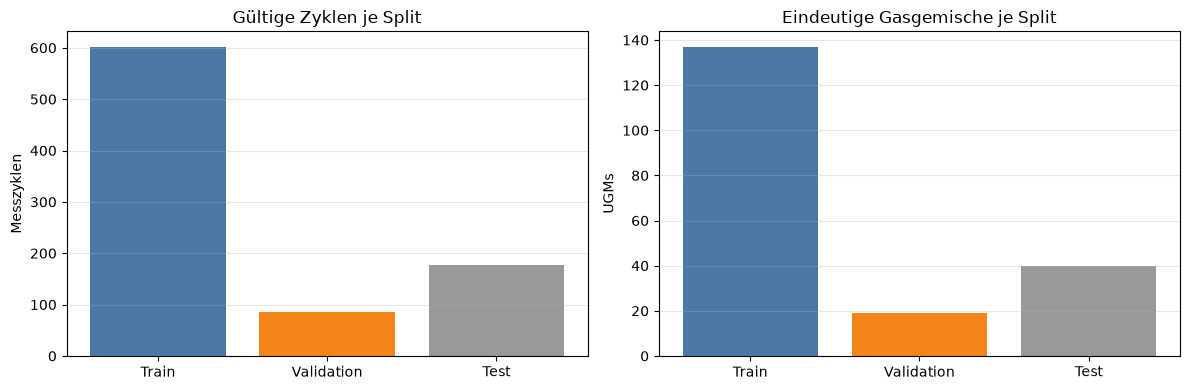

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([row['Split'] for row in split_df], [row['physische Messzyklen'] for row in split_df], color=['#4c78a8','#f58518','#999999'])
axes[0].set(ylabel='Messzyklen', title='Gültige Zyklen je Split')
axes[1].bar([row['Split'] for row in split_df], [row['eindeutige UGMs'] for row in split_df], color=['#4c78a8','#f58518','#999999'])
axes[1].set(ylabel='UGMs', title='Eindeutige Gasgemische je Split')
for axis in axes: axis.grid(True, axis='y', alpha=.3)
fig.tight_layout(); plt.show()

## 4. Gaszusammensetzung und Konzentrationsbereiche

Die Tabelle beschreibt alle sieben Gas-Komponenten auf genau den 688 Messzeilen, die für Global-6-HPO als Train oder Validation zugelassen sind. Nur Aceton wird gelernt; die anderen Konzentrationen zeigen die gleichzeitig variierenden Interferenzen. Alle Gaskonzentrationen werden entsprechend dem Datensatz in ppb angegeben.

In [6]:
cal1_mask = np.asarray(prepared_target['calibration']).ravel() == 1
if len(raw_target['acetone']) != int(cal1_mask.sum()):
    raise AssertionError('Kalibration-1-Zeilen sind nicht mit der Ursprungsdatei ausgerichtet.')
cal1_split = np.asarray(prepared_target['split_code']).ravel()[cal1_mask]
hpo_rows = np.isin(cal1_split, [1, 2])
gas_rows = []
for key in gas_keys:
    values = np.asarray(raw_target[key], dtype=float).ravel()[hpo_rows]
    finite = values[np.isfinite(values)]
    gas_rows.append({
        'Gas': GAS_LABELS[key], 'Einheit': 'ppb', 'Minimum': finite.min(),
        'Median': np.median(finite), 'Maximum': finite.max(),
        'unterschiedliche Konzentrationen': len(np.unique(finite)),
        'Zyklen > 0': int(np.count_nonzero(finite > 0)),
        'Anteil > 0 [%]': 100 * np.mean(finite > 0),
        'Modellziel': key == 'acetone',
    })
gas_df = sorted(gas_rows, key=lambda row: row['Gas'])
show_table(gas_df)

Gas,Einheit,Minimum,Median,Maximum,unterschiedliche Konzentrationen,Zyklen > 0,Anteil > 0 [%],Modellziel
Aceton,ppb,1.7,145.3,299.3,156,688,100.0,True
Ethanol,ppb,1.7,145.3,299.3,156,688,100.0,False
Ethylacetat,ppb,1.7,154.95,299.3,156,688,100.0,False
Formaldehyd,ppb,1.7,140.05,297.8,156,688,100.0,False
Kohlenmonoxid,ppb,142.8,1073.8,1985.8,156,688,100.0,False
Toluol,ppb,3.2,149.8,299.3,156,688,100.0,False
Wasserstoff,ppb,403.8,1161.3,1896.3,156,688,100.0,False


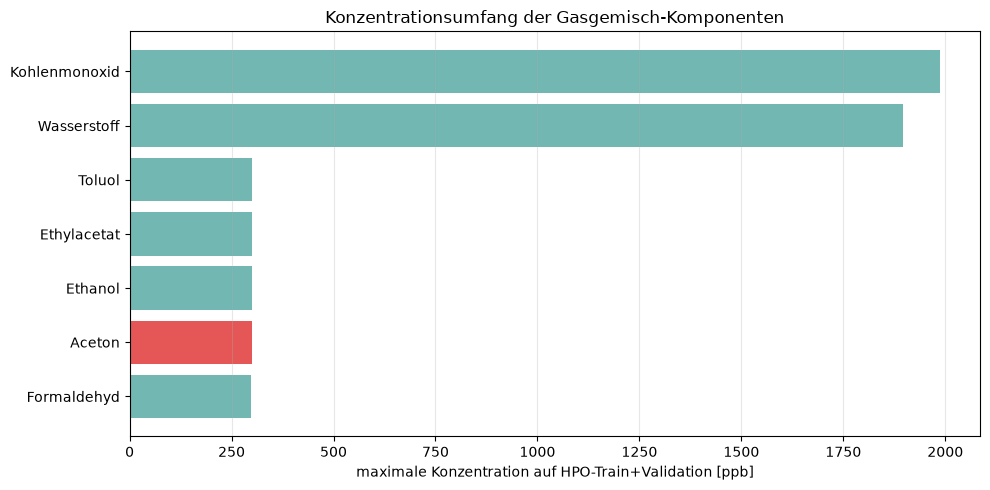

In [7]:
ordered = sorted(gas_df, key=lambda row: row['Maximum'])
fig, axis = plt.subplots(figsize=(10, 5))
axis.barh([row['Gas'] for row in ordered], [row['Maximum'] for row in ordered], color=['#e45756' if row['Modellziel'] else '#72b7b2' for row in ordered])
axis.set(xlabel='maximale Konzentration auf HPO-Train+Validation [ppb]',
         title='Konzentrationsumfang der Gasgemisch-Komponenten')
axis.grid(True, axis='x', alpha=.3); fig.tight_layout(); plt.show()

## 5. Aceton-Verteilung nach Split

Hier ist die tatsächlich vorhergesagte Zielgröße dargestellt. Die Verteilung wird sowohl pro Messzyklus als auch pro UGM-Mittelwert gezeigt.

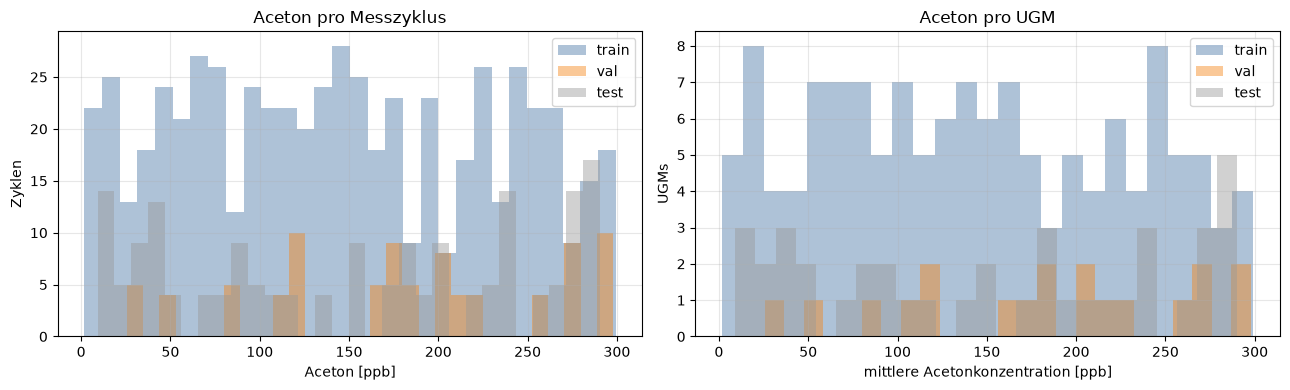

Split,Minimum [ppb],Median [ppb],Maximum [ppb],verschiedene Zykluswerte,UGMs
train,1.7000000476837158,140.8000030517578,299.29998779296875,137,137
val,25.700000762939453,185.60000610351562,297.79998779296875,19,19
test,9.199999809265137,169.1999969482422,290.29998779296875,40,40


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
acetone_summary = []
for split, color in [('train', '#4c78a8'), ('val', '#f58518'), ('test', '#999999')]:
    values = domains[sources[0]][split]['y']
    groups = domains[sources[0]][split]['groups']
    axes[0].hist(values, bins=30, alpha=.45, label=split, color=color)
    unique = np.unique(groups)
    ugm_means = np.asarray([values[groups == group].mean() for group in unique])
    axes[1].hist(ugm_means, bins=25, alpha=.45, label=split, color=color)
    acetone_summary.append({'Split': split, 'Minimum [ppb]': float(values.min()),
                             'Median [ppb]': float(np.median(values)),
                             'Maximum [ppb]': float(values.max()),
                             'verschiedene Zykluswerte': int(len(np.unique(values))),
                             'UGMs': int(len(unique))})
axes[0].set(xlabel='Aceton [ppb]', ylabel='Zyklen', title='Aceton pro Messzyklus')
axes[1].set(xlabel='mittlere Acetonkonzentration [ppb]', ylabel='UGMs', title='Aceton pro UGM')
for axis in axes: axis.grid(True, alpha=.3); axis.legend()
fig.tight_layout(); plt.show()
show_table(acetone_summary)

## 6. Wie viele Zyklen gehören zu einer UGM?

Die UGM-Gruppierung verhindert, dass Wiederholungszyklen desselben Gasgemischs auf verschiedene Splits verteilt werden. Metriken werden zuerst innerhalb der UGM gemittelt.

Split,UGMs,min Zyklen/UGM,Median Zyklen/UGM,Mittel Zyklen/UGM,max Zyklen/UGM
train,137,4,4.0,4.394160583941606,5
val,19,4,5.0,4.526315789473684,5
test,40,4,4.0,4.45,5


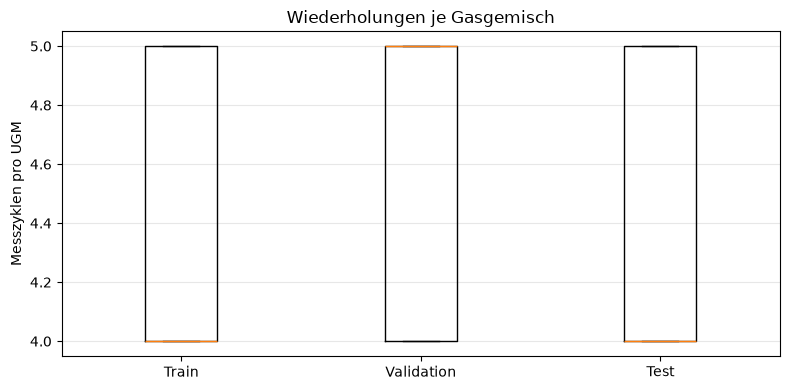

In [9]:
group_rows = []
sizes_by_split = {}
for split in ['train', 'val', 'test']:
    groups = domains[sources[0]][split]['groups']
    _, sizes = np.unique(groups, return_counts=True)
    sizes_by_split[split] = sizes
    group_rows.append({'Split': split, 'UGMs': len(sizes), 'min Zyklen/UGM': sizes.min(),
                       'Median Zyklen/UGM': np.median(sizes),
                       'Mittel Zyklen/UGM': sizes.mean(), 'max Zyklen/UGM': sizes.max()})
show_table(group_rows)
fig, axis = plt.subplots(figsize=(8, 4))
axis.boxplot([sizes_by_split[name] for name in ['train','val','test']],
             tick_labels=['Train','Validation','Test'])
axis.set(ylabel='Messzyklen pro UGM', title='Wiederholungen je Gasgemisch')
axis.grid(True, axis='y', alpha=.3); fig.tight_layout(); plt.show()

## 7. Geräte, Subsensoren und Signalform

Jede Gerätedatei enthält vier sensitive Subsensoren mit je 1.440 Zeitpunkten pro Zyklus. Für Global-6 und Transfer wird absichtlich nur die Variable `sensor0` geladen.

In [10]:
sensor_rows = []
for index, sensor in enumerate(sensors):
    path = PREPARED / f'dennis_SGP40_{sensor}.mat'
    variables = [name for name, shape, kind in whosmat(path) if '_sensor' in name]
    sensor_rows.append({
        'Gerät': sensor, 'Rolle': 'Global-6-Quelle' if sensor in sources else 'Transferziel',
        'vorhandene Subsensoren': len(variables), 'verwendeter Subsensor': 0,
        'Gesamtzeilen beider Kalibrationen': next(shape[0] for name, shape, kind in whosmat(path) if name.endswith('_sensor0')),
        'Samples/Zyklus': next(shape[1] for name, shape, kind in whosmat(path) if name.endswith('_sensor0')),
        'in Global-HPO': sensor in sources,
    })
show_table(sensor_rows)

Gerät,Rolle,vorhandene Subsensoren,verwendeter Subsensor,Gesamtzeilen beider Kalibrationen,Samples/Zyklus,in Global-HPO
54118801,Global-6-Quelle,4,0,5483,1440,True
54120037,Global-6-Quelle,4,0,5483,1440,True
54120457,Global-6-Quelle,4,0,5483,1440,True
54156953,Global-6-Quelle,4,0,5483,1440,True
84746449,Global-6-Quelle,4,0,5483,1440,True
84748697,Global-6-Quelle,4,0,5483,1440,True
84749569,Transferziel,4,0,5483,1440,False


## Kernaussage

- Der ursprüngliche Kalibration-1-Datensatz enthält **7 Gase plus Feuchte** in variierenden Gemischen.
- Es gibt **199 definierte UGMs**; 3 sind nicht paarbar. Von den 196 auswertbaren UGMs sind 156 für Entwicklung/HPO und 40 ausschließlich für den Test vorgesehen.
- Das aktuelle Global-6-Modell lernt **nur Aceton** als Regressionsziel.
- HPO verwendet **6 Geräte × Subsensor 0**, 3.612 gepoolte Trainingszyklen und 516 gepoolte Validierungszyklen.
- Das entspricht 137 Train-UGMs und 19 Validierungs-UGMs; durch sensorgetrennte Auswertung entstehen 822 bzw. 114 Sensor-UGM-Gruppen.
- Gerät 7 und der Testsplit bleiben aus der HPO ausgeschlossen.